# NeqSim Tieback and Subsea Screening

This notebook supports Chapter 13. It compares candidate host facilities with `TiebackAnalyzer` and then models a selected subsea manifold-cluster architecture with `SubseaProductionSystem`.


In [ ]:
from pathlib import Path
import sys
import subprocess

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

FIGURES_DIR = NOTEBOOK_DIR.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

PROJECT_ROOT = NOTEBOOK_DIR
for candidate in [NOTEBOOK_DIR] + list(NOTEBOOK_DIR.parents):
    if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
        PROJECT_ROOT = candidate
        break

sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
JClass = ns.JClass
ArrayList = JClass("java.util.ArrayList")

FieldConcept = JClass("neqsim.process.fielddevelopment.concept.FieldConcept")
TiebackAnalyzer = JClass("neqsim.process.fielddevelopment.tieback.TiebackAnalyzer")
HostFacility = JClass("neqsim.process.fielddevelopment.tieback.HostFacility")
SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
SubseaProductionSystem = JClass("neqsim.process.fielddevelopment.subsea.SubseaProductionSystem")
SubseaArchitecture = JClass("neqsim.process.fielddevelopment.subsea.SubseaProductionSystem$SubseaArchitecture")

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures: {FIGURES_DIR}")


Project root: C:\Users\ESOL\Documents\GitHub\neqsim
Figures: C:\Users\ESOL\Documents\GitHub\neqsim\neqsim-paperlab\books\tpg4230_field_development_and_operations_2026\chapters\ch13_subsea_surf_systems\figures


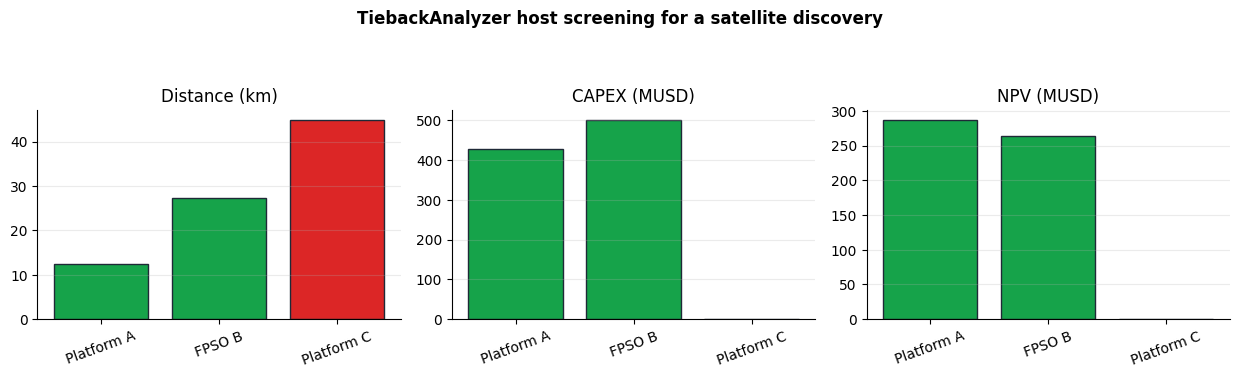

TIEBACK ANALYSIS REPORT: Satellite Discovery
Discovery location: 61.6000°N, 2.4000°E
Options evaluated: 3
Feasible options: 2
Profitable options: 2

----------------------------------------------------------------------
Host                 Distance      CAPEX        NPV      IRR     Status
                         (km)     (MUSD)     (MUSD)      (%)           
----------------------------------------------------------------------
Platform A               12.3      426.8      286.4     26.6     VIABLE
FPSO B                   27.3      499.4      263.4     23.2     VIABLE
Platform C               44.8        0.0        0.0      0.0       FAIL
----------------------------------------------------------------------

BEST OPTION: Platform A
  Distance: 12.3 km
  CAPEX: 426.8 MUSD
  NPV: 286.4 MUSD
  IRR: 26.6%
  Payback: 4.0 years
  Flow Assurance: PASS



In [2]:
discovery = FieldConcept.gasTieback("Satellite Discovery", 25.0, 3, 1.2)

hosts = ArrayList()
host_specs = [
    ("Platform A", 61.50, 2.30, 120.0, 5.0, 20000.0, 80.0),
    ("FPSO B", 61.80, 2.10, 350.0, 8.0, 50000.0, 70.0),
    ("Platform C", 62.00, 2.50, 90.0, 2.0, 12000.0, 90.0),
]
for name, lat, lon, depth, gas_cap, oil_cap, min_pressure in host_specs:
    hosts.add(HostFacility.builder(name)
              .location(lat, lon)
              .waterDepth(depth)
              .spareGasCapacity(gas_cap)
              .spareOilCapacity(oil_cap)
              .minTieInPressure(min_pressure)
              .build())

analyzer = TiebackAnalyzer()
report = analyzer.analyze(discovery, hosts, 61.60, 2.40)
options = [report.getOptions().get(i) for i in range(report.getOptionCount())]

host_names = [str(opt.getHostName()) for opt in options]
npv = [float(opt.getNpvMusd()) for opt in options]
capex = [float(opt.getTotalCapexMusd()) for opt in options]
distance = [float(opt.getDistanceKm()) for opt in options]
feasible = [bool(opt.isFeasible()) for opt in options]
colors = ["#16a34a" if ok else "#dc2626" for ok in feasible]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
axes[0].bar(host_names, distance, color=colors, edgecolor="#1f2937")
axes[0].set_title("Distance (km)")
axes[1].bar(host_names, capex, color=colors, edgecolor="#1f2937")
axes[1].set_title("CAPEX (MUSD)")
axes[2].bar(host_names, npv, color=colors, edgecolor="#1f2937")
axes[2].set_title("NPV (MUSD)")
for ax in axes:
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelrotation=20)

fig.suptitle("TiebackAnalyzer host screening for a satellite discovery", fontsize=12, weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.9))
fig.savefig(FIGURES_DIR / "ch13_neqsim_tieback_host_screen.png", dpi=160, bbox_inches="tight")
plt.show()

print(report.getSummary())


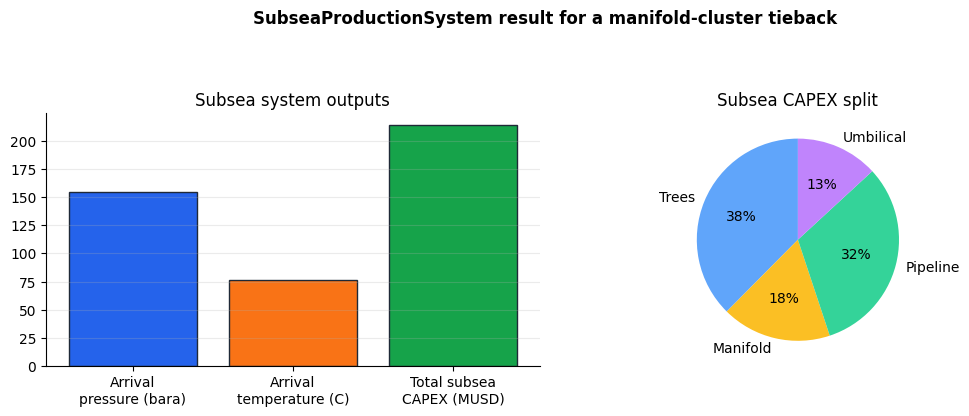

# Subsea Production System: Teaching subsea system

## Configuration

| Parameter | Value |
|-----------|-------|
| Architecture | MANIFOLD_CLUSTER |
| Water Depth | 300 m |
| Tieback Distance | 25.0 km |
| Well Count | 3 |
| Flowline Diameter | 12" |

## Operating Conditions

| Parameter | Value |
|-----------|-------|
| Arrival Pressure | 154.3 bara |
| Arrival Temperature | 76.3 °C |
| Total Production | 3.00 MSm3/d |
| Total Pressure Drop | -27.8 bar |

## Subsea CAPEX

| Component | Cost (MUSD) |
|-----------|-------------|
| Subsea Trees | 75 |
| Manifolds | 35 |
| Pipeline | 63 |
| Umbilicals | 26 |
| Control Systems | 14 |
| **Total** | **214** |



In [3]:
fluid = SystemSrkEos(273.15 + 80.0, 180.0)
for component, amount in [("methane", 0.90), ("ethane", 0.05), ("propane", 0.03), ("n-butane", 0.02)]:
    fluid.addComponent(component, amount)
fluid.setMixingRule("classic")

subsea = SubseaProductionSystem("Teaching subsea system")
subsea.setArchitecture(SubseaArchitecture.MANIFOLD_CLUSTER)
subsea.setWaterDepthM(300.0)
subsea.setTiebackDistanceKm(25.0)
subsea.setWellCount(3)
subsea.setReservoirFluid(fluid)
subsea.setWellheadConditions(160.0, 70.0)
subsea.setRatePerWell(1.0e6)
subsea.setFlowlineDiameterInches(12.0)
subsea.setSeabedTemperatureC(4.0)
subsea.build()
subsea.run()
result = subsea.getResult()

labels = ["Trees", "Manifold", "Pipeline", "Umbilical"]
values = [
    float(result.getSubseaTreeCostMusd()),
    float(result.getManifoldCostMusd()),
    float(result.getPipelineCostMusd()),
    float(result.getUmbilicalCostMusd()),
]
arrival_labels = ["Arrival\npressure (bara)", "Arrival\ntemperature (C)", "Total subsea\nCAPEX (MUSD)"]
arrival_values = [
    float(result.getArrivalPressureBara()),
    float(result.getArrivalTemperatureC()),
    float(result.getTotalSubseaCapexMusd()),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.05, 1.2]})
axes[0].bar(arrival_labels, arrival_values, color=["#2563eb", "#f97316", "#16a34a"], edgecolor="#1f2937")
axes[0].set_title("Subsea system outputs")
axes[0].grid(axis="y", alpha=0.25)
axes[1].pie(values, labels=labels, autopct="%1.0f%%", startangle=90,
            colors=["#60a5fa", "#fbbf24", "#34d399", "#c084fc"])
axes[1].set_title("Subsea CAPEX split")
for ax in axes[:1]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.suptitle("SubseaProductionSystem result for a manifold-cluster tieback", fontsize=12, weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.9))
fig.savefig(FIGURES_DIR / "ch13_neqsim_subsea_system_result.png", dpi=160, bbox_inches="tight")
plt.show()

print(result.getSummary())
